In [21]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [22]:
fund = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

In [23]:
nifty = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [24]:
# Keep only NIFTY100 data
nifty = nifty[nifty["index_name"] == "NIFTY100"].copy()

# Convert date
nifty["date"] = pd.to_datetime(nifty["date"])

# Sort by date
nifty = nifty.sort_values("date")

# Calculate daily market returns
nifty["market_return"] = nifty["close_value"].pct_change()

# Remove first NaN row
nifty = nifty.dropna(subset=["market_return"])

In [25]:
print(nifty.head())

           date index_name  close_value  market_return
1151 2022-01-04   NIFTY100     17537.52      -0.013540
1152 2022-01-05   NIFTY100     17607.73       0.004003
1153 2022-01-06   NIFTY100     17556.05      -0.002935
1154 2022-01-07   NIFTY100     17664.02       0.006150
1155 2022-01-10   NIFTY100     17516.51      -0.008351


In [26]:
# Prepare Fund Data
fund["date"] = pd.to_datetime(fund["date"])

In [27]:
# Merge Dataset
merged = fund.merge(
    nifty[["date", "market_return"]],
    on="date",
    how="inner"
)

In [28]:
# Calculate Alpha & Beta
results = []

for amfi_code, group in merged.groupby("amfi_code"):

    regression = linregress(
        group["market_return"],
        group["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    results.append({
        "amfi_code": amfi_code,
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": regression.rvalue ** 2,
        "P_value": regression.pvalue
    })

alpha_beta_df = pd.DataFrame(results)

In [29]:
# Rank by Alpha
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

print(alpha_beta_df.head())

    amfi_code     Alpha      Beta  R_squared   P_value
21     119598  0.307037 -0.026140   0.000179  0.650377
39     149324  0.303182  0.009366   0.000024  0.869482
25     120505  0.297386 -0.003264   0.000005  0.941151
36     148569  0.281011  0.019493   0.000202  0.630770
2      100033  0.275189  0.002507   0.000003  0.953982


In [30]:
# Save CSV
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta_analysis.csv",
    index=False
)

print("Alpha Beta analysis saved successfully!")

Alpha Beta analysis saved successfully!


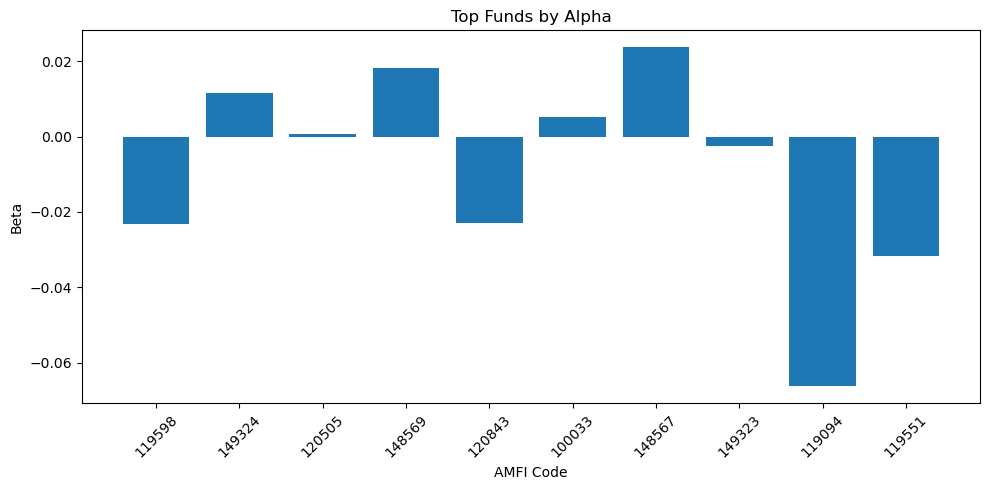

In [18]:
# Beta Chart
top10 = alpha_beta_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Beta"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")

plt.ylabel("Beta")

plt.title("Top Funds by Alpha")

plt.tight_layout()

plt.savefig("../reports/19_alpha_beta_analysis.png")

plt.show()

In [20]:
## Insight

# Linear regression was used to estimate Alpha and Beta for each mutual fund against the Nifty 100 benchmark. Beta measures the fund's sensitivity to market movements, while Alpha represents the annualized excess return after accounting for market risk. Funds with higher Alpha generated superior risk-adjusted performance.